In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

sns.set_theme(style="whitegrid")
SEED = 42

In [2]:
df = pd.read_csv(r"C:\Users\Shivam Singh\Downloads\diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# View basic info and data types
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Check summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [5]:
# Check for null values and duplicates
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0


Outcome
0    500
1    268
Name: count, dtype: int64


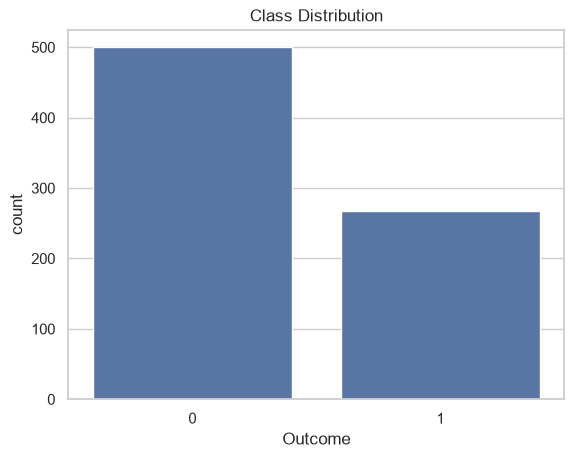

In [6]:
# Check target variable distribution
if 'Outcome' in df.columns:
    print(df['Outcome'].value_counts())
    sns.countplot(x='Outcome', data=df)
    plt.title("Class Distribution")
    plt.show()

In [7]:
# List of columns where 0 is invalid
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN
df[zero_cols] = df[zero_cols].replace(0, np.nan)

# Fill NaNs with the median value of each column
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())

# Confirm no NaNs remain
print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [8]:
# Define X and y
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (614, 8)
Testing set shape: (154, 8)


In [9]:
# Build a pipeline for Logistic Regression (includes feature scaling)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=SEED))
])

# Build Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)

# Fit models on training data
lr_pipeline.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Make predictions on test set
lr_preds = lr_pipeline.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Evaluate model performance
print("=== Logistic Regression Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.4f}")
print(f"F1-Score:  {f1_score(y_test, lr_preds):.4f}")

print("\n=== Random Forest Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_preds):.4f}")
print(f"F1-Score:  {f1_score(y_test, rf_preds):.4f}")

=== Logistic Regression Performance ===
Accuracy:  0.7078
F1-Score:  0.5455

=== Random Forest Performance ===
Accuracy:  0.7792
F1-Score:  0.6531


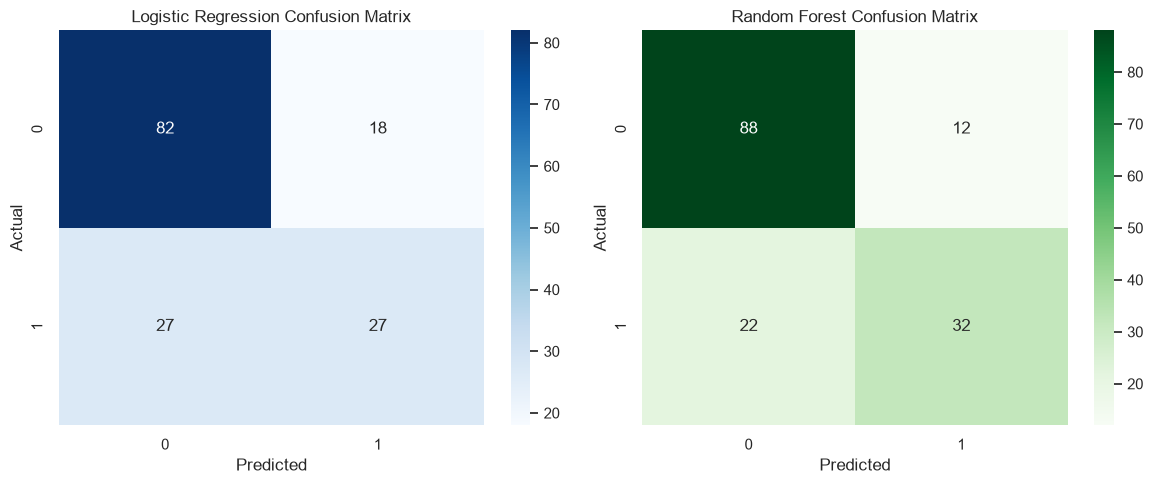

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Matrix
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Matrix
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

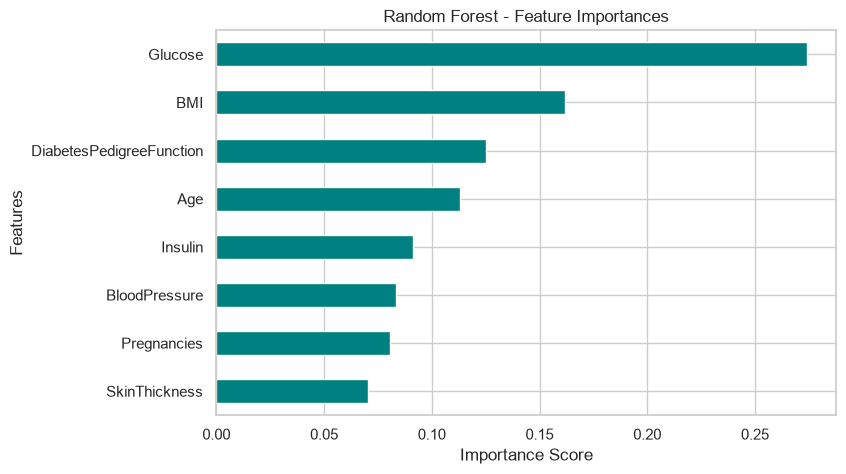

In [11]:
# Extract feature importances from the trained Random Forest model
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

# Plot feature importances
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='teal')
plt.title('Random Forest - Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [12]:
# Define hyperparameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# Initialize Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid,
    cv=5,
    scoring='f1'
)

# Fit grid search on training data
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# Evaluate tuned model on test set
best_preds = best_rf.predict(X_test)

print("=== Tuned Random Forest Performance ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned Accuracy:  {accuracy_score(y_test, best_preds):.4f}")
print(f"Tuned F1-Score:  {f1_score(y_test, best_preds):.4f}")

=== Tuned Random Forest Performance ===
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Accuracy:  0.7792
Tuned F1-Score:  0.6531


In [13]:
# Pass new patient data as a DataFrame with matching column names
#[Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
new_patient = pd.DataFrame(
    [[2, 140, 70, 25, 100, 28.5, 0.45, 35]], 
    columns=X.columns
)

# Predict class and probability without warnings
prediction = best_rf.predict(new_patient)[0]
probability = best_rf.predict_proba(new_patient)[0][1]

# Display outcome
result = "Diabetic (1)" if prediction == 1 else "Non-Diabetic (0)"
print("=== Individual Patient Diagnosis ===")
print(f"Predicted Class:        {result}")
print(f"Diabetes Probability:   {probability * 100:.2f}%")

=== Individual Patient Diagnosis ===
Predicted Class:        Non-Diabetic (0)
Diabetes Probability:   44.00%


In [14]:
# Pass new patient data as a DataFrame with matching column names
#[Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]
new_patient = pd.DataFrame(
    [[2, 170, 800, 35, 120, 38.5, 0.85, 45]], 
    columns=X.columns
)

# Predict class and probability without warnings
prediction = best_rf.predict(new_patient)[0]
probability = best_rf.predict_proba(new_patient)[0][1]

# Display outcome
result = "Diabetic (1)" if prediction == 1 else "Non-Diabetic (0)"
print("=== Individual Patient Diagnosis ===")
print(f"Predicted Class:        {result}")
print(f"Diabetes Probability:   {probability * 100:.2f}%")

=== Individual Patient Diagnosis ===
Predicted Class:        Diabetic (1)
Diabetes Probability:   67.00%


In [15]:
import joblib

# Save model to file
joblib.dump(best_rf, 'diabetes_rf_model.pkl')
print("Model saved successfully as 'diabetes_rf_model.pkl'!")

# How to reload it in another script/app:
# loaded_model = joblib.load('diabetes_rf_model.pkl')

Model saved successfully as 'diabetes_rf_model.pkl'!


In [16]:
from sklearn.metrics import classification_report

print("=== Final Model Classification Report ===")
print(classification_report(y_test, best_preds, target_names=['Non-Diabetic', 'Diabetic']))

=== Final Model Classification Report ===
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.88      0.84       100
    Diabetic       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154

